# Data preparation

In [1]:
from utils import load_data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
sns.set_theme(style="darkgrid")

In [2]:
df = load_data("police")
df.head()

,id,road_category,road_number,date,time,accident_type,collision_type,fixed_obstacle_type,accident_character,responsibility,...,accident_type_label,collision_type_label,fixed_obstacle_type_label,accident_character_label,driver_alcohol_level,driver_alcohol_detected,year,month,day_of_week,hour
0,60040220005,0.0,1.0,2022-01-31,1615,1,4,0,1,1,...,Moving vehicle,Rear,N/A,Injury/Fatality,no_alcohol,0,2022,1,Monday,16
1,60040220014,0.0,1.0,2022-02-21,2560,3,0,4,2,1,...,Fixed object,N/A,Guardrail,Material Damage Only,not_tested,<NA>,2022,2,Monday,<NA>
2,60040220020,0.0,1.0,2022-04-21,405,1,4,0,1,1,...,Moving vehicle,Rear,N/A,Injury/Fatality,no_alcohol,0,2022,4,Thursday,4
3,60040220030,0.0,1.0,2022-05-25,1015,1,4,0,2,1,...,Moving vehicle,Rear,N/A,Material Damage Only,no_alcohol,0,2022,5,Wednesday,10
4,60040220035,0.0,1.0,2022-06-06,2150,6,0,0,2,4,...,Domestic animal,N/A,N/A,Material Damage Only,not_tested,<NA>,2022,6,Monday,21


In [3]:
target = "accident_character_label"

In [4]:
leakage_features = [
    "fatalities",
    "serious_injuries",
    "minor_injuries",
    "total_material_damage",
    "extrication_method",
    "post_accident_vehicle_state",
    "leakage",
    "damage_on_vehicle",
    "accident_character"
]

drop_features = [
    "id",
    "date",   # already have month/day/week and so on
    "geom",
    "geog",
    "x",
    "y",      # not a spatial model
    target
] + leakage_features

In [5]:
df_model = df.drop(columns=[col for col in drop_features if col in df.columns]).copy()

y = df[target].copy()
X = df_model.copy()

X["hour"] = pd.to_numeric(X["hour"], errors="coerce")
X["vehicle_year"] = pd.to_numeric(X["vehicle_year"], errors="coerce")

In [6]:
categorical_cols = [
    "location_admin",
    "region",
    "district",
    "police_unit",
    "locality_type",
    "locality_type_label",
    
    "accident_type",
    "accident_type_label",
    "collision_type",
    "collision_type_label",
    "fixed_obstacle_type",
    "fixed_obstacle_type_label",
    "animal_type",

    "accident_character",
    "accident_character_label",
    "responsibility",

    "alcohol_at_driver",
    "driver_alcohol_level",
    "driver_alcohol_detected",
    "drugs_at_driver",

    "main_cause",

    "road_surface_type",
    "road_surface_condition",
    "road_condition",
    "weather_conditions",
    "visibility",
    "sight_conditions",
    "road_division",

    "accident_position_on_road",
    "traffic_control",
    "local_priority_arrangement",
    "specific_places",
    "road_geometry",

    "pedestrian_category",
    "pedestrian_reflective",
    "pedestrian_on_micromobility",
    "pedestrian_state",
    "pedestrian_alcohol",
    "pedestrian_drug_type",
    "pedestrian_behaviour",
    "pedestrian_outcome",
    "pedestrian_gender",
    "pedestrian_nationality",
    "first_aid_given",
    "pedestrian_consequences",

    "place_of_accident",
    "road_category",
    "road_number",
    "crossing_road_type",

    "vehicle_type",
    "vehicle_make",
    "vehicle_info",
    "fuel_type",
    "tire_type",
    "vehicle_owner_type",
    "skid",

    "post_accident_vehicle_state",
    "leakage",
    "extrication_method",
    "vehicle_position",
    "damage_on_vehicle",

    "driver_category",
    "driver_condition",
    "external_influence_on_driver",

    "in_vehicle_consequences",
    "person_role",
    "person_detail",
    "person_gender",
    "person_nationality",
    "person_first_aid",
    "person_consequences",

    "day_of_week"
]

numeric_cols = [
    "fatalities",
    "serious_injuries",
    "minor_injuries",
    "total_material_damage",
    "number_vehicles",
    "vehicle_year",
    "pedestrian_age",
    "person_age",
    "year",
    "month",
    "hour"
]

numeric_cols = [col for col in numeric_cols if col not in drop_features and col in X.columns]
categorical_cols = [col for col in categorical_cols if col not in drop_features and col in X.columns]


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Pipelines
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [8]:
X["driver_alcohol_detected"] = X["driver_alcohol_detected"].astype("float64")

In [ ]:
from sklearn.model_selection import train_test_split

X["driver_alcohol_detected"] = pd.to_numeric(X["driver_alcohol_detected"], errors="coerce")

# split the set in statified manner, as target is not 50/50 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.replace({pd.NA: np.nan})
X_test = X_test.replace({pd.NA: np.nan})

# Feature Importance via Random Forest

### Model Creation and fitting

In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Model learning
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Model evaluation

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf_pipeline.predict(X_test)
pos_index = list(rf_pipeline.classes_).index("Injury/Fatality")
y_proba = rf_pipeline.predict_proba(X_test)[:, pos_index]
print(classification_report(y_test, y_pred))

print(rf_pipeline.classes_)

if y_proba is not None:
    # choose positive class index if needed
    print("ROC-AUC:", roc_auc_score((y_test == "Injury/Fatality").astype(int), y_proba))

                      precision    recall  f1-score   support

     Injury/Fatality       0.81      0.81      0.81      1236
Material Damage Only       0.92      0.92      0.92      3125

            accuracy                           0.89      4361
           macro avg       0.87      0.87      0.87      4361
        weighted avg       0.89      0.89      0.89      4361

['Injury/Fatality' 'Material Damage Only']
ROC-AUC: 0.9583113268608415


### Feature importance

In [ ]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# print(fi_df.head(20))

print(fi_df.to_string())

import matplotlib.pyplot as plt

                                                           feature    importance
88                            cat__driver_alcohol_level_not_tested  4.715566e-02
73                                        cat__alcohol_at_driver_2  4.289353e-02
71                                        cat__alcohol_at_driver_0  4.259424e-02
11                                            cat__accident_type_2  4.021589e-02
87                            cat__driver_alcohol_level_no_alcohol  3.674018e-02
23                         cat__accident_type_label_Parked vehicle  3.421838e-02
13                                            cat__accident_type_4  2.971549e-02
24                             cat__accident_type_label_Pedestrian  2.515331e-02
140                                            cat__main_cause_508  2.333049e-02
4                                                        num__hour  1.997747e-02
3                                                       num__month  1.731912e-02
2                           

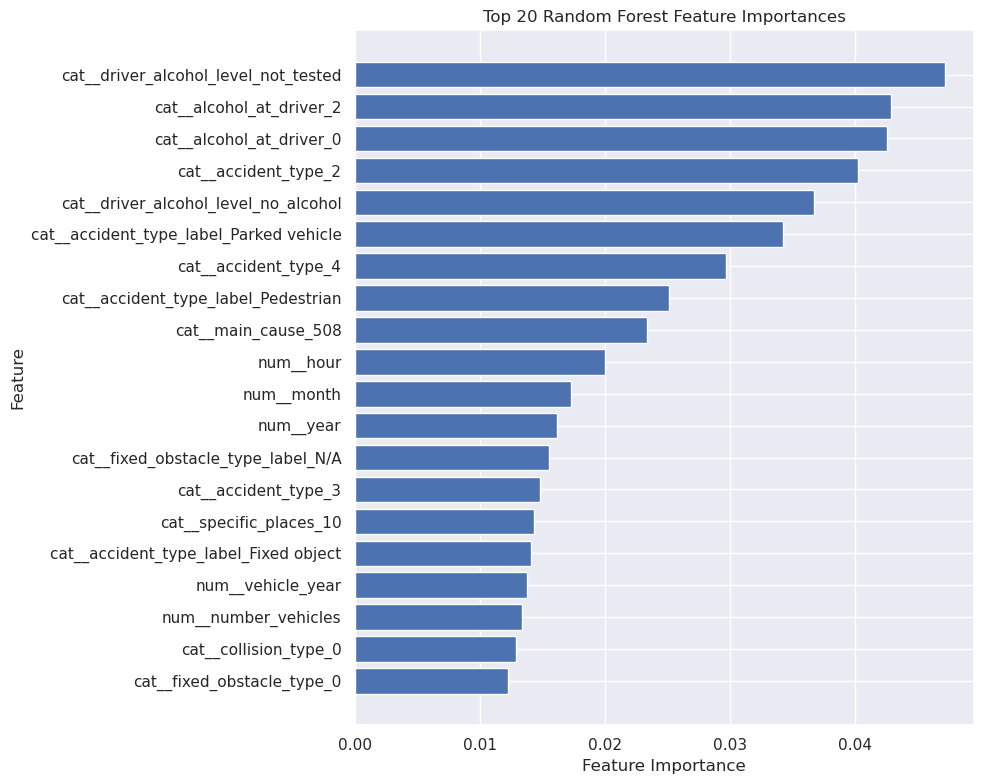

In [ ]:
top_n = 20
top_fi = fi_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
def extract_original_feature_name(transformed_name):
    # examples:
    # num__hour -> hour
    # cat__collision_type_label_Rear -> collision_type_label
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "")
    elif transformed_name.startswith("cat__"):
        rest = transformed_name.replace("cat__", "")
        
        # try to match original categorical column names
        for col in categorical_cols:
            prefix = col + "_"
            if rest.startswith(prefix):
                return col
        return rest
    return transformed_name

fi_df["original_feature"] = fi_df["feature"].apply(extract_original_feature_name)

grouped_fi = (
    fi_df.groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
) # type: ignore

print(grouped_fi.head(20))

        original_feature  importance
1          accident_type    0.201091
2      alcohol_at_driver    0.088683
8   driver_alcohol_level    0.087236
17            main_cause    0.053950
13   fixed_obstacle_type    0.049706
4         collision_type    0.043861
33          vehicle_make    0.036008
31       specific_places    0.033394
36          vehicle_type    0.028863
6            day_of_week    0.024093
35      vehicle_position    0.022879
24         road_division    0.021085
21        responsibility    0.021077
14                  hour    0.019977
9        driver_category    0.019841
34    vehicle_owner_type    0.019429
25         road_geometry    0.018463
18                 month    0.017319
22         road_category    0.016760
40                  year    0.016137


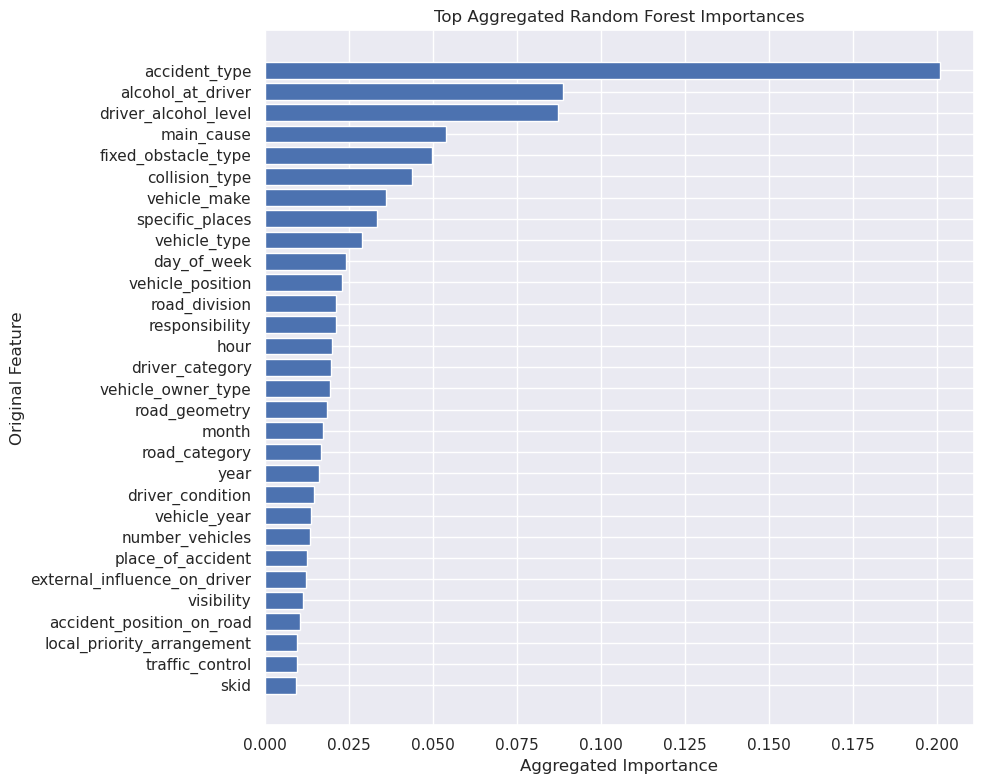

In [ ]:
top_grouped = grouped_fi.head(30).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_grouped["original_feature"], top_grouped["importance"])
plt.xlabel("Aggregated Importance")
plt.ylabel("Original Feature")
plt.title("Top Aggregated Random Forest Importances")
plt.tight_layout()
plt.show()


Feature importance analysis based on the trained Random Forest classifier indicates that the most influential predictors of accident severity are primarily related to accident characteristics and driver conditions.

The most important feature is accident_type, suggesting that the type of accident plays the strongest role in determining accident severity. Variables related to driver alcohol involvement, including alcohol_at_driver and driver_alcohol_level, also show high importance, indicating a strong relationship between alcohol presence and severe accidents.

# SHAP analysis

SHAP anlaysis doesn't require pipeline

### Model creation


In [23]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

# categorical -> string
for col in categorical_cols:
    X_train_cb[col] = X_train_cb[col].astype("string").fillna("Missing")
    X_test_cb[col] = X_test_cb[col].astype("string").fillna("Missing")

# numeric -> numeric
for col in numeric_cols:
    X_train_cb[col] = pd.to_numeric(X_train_cb[col], errors="coerce")
    X_test_cb[col] = pd.to_numeric(X_test_cb[col], errors="coerce")

categorical_indices = [X_train_cb.columns.get_loc(col) for col in categorical_cols]

model_cb = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=100,
    random_seed=42
)

for col in categorical_cols:
    if pd.api.types.is_float_dtype(X_train[col]):
        print("Float categorical:", col)

model_cb.fit(
    X_train_cb, y_train,
    cat_features=categorical_indices,
    eval_set=(X_test_cb, y_test),
    use_best_model=True
)

preds = model_cb.predict(X_test_cb)
print(classification_report(y_test, preds))

Float categorical: road_category
Float categorical: road_number
Float categorical: crossing_road_type
0:	test: 0.9263313	best: 0.9263313 (0)	total: 35.4ms	remaining: 17.6s
100:	test: 0.9577014	best: 0.9577052 (99)	total: 4.44s	remaining: 17.5s
200:	test: 0.9595526	best: 0.9595526 (200)	total: 8.7s	remaining: 12.9s
300:	test: 0.9602413	best: 0.9602695 (295)	total: 13.3s	remaining: 8.82s
400:	test: 0.9608872	best: 0.9608872 (400)	total: 18s	remaining: 4.45s
499:	test: 0.9614752	best: 0.9614967 (494)	total: 21.8s	remaining: 0us

bestTest = 0.961496699
bestIteration = 494

Shrink model to first 495 iterations.
                      precision    recall  f1-score   support

     Injury/Fatality       0.82      0.81      0.82      1236
Material Damage Only       0.93      0.93      0.93      3125

            accuracy                           0.90      4361
           macro avg       0.87      0.87      0.87      4361
        weighted avg       0.90      0.90      0.90      4361



In [24]:
cb_importance = model_cb.get_feature_importance()
cb_fi_df = pd.DataFrame({
    "feature": X.columns,
    "importance": cb_importance
}).sort_values("importance", ascending=False)

print(cb_fi_df.head(20))

                    feature  importance
37      accident_type_label   18.068977
41  driver_alcohol_detected   10.218307
3             accident_type    7.482402
24             vehicle_type    5.901451
40     driver_alcohol_level    5.846917
8                main_cause    4.979670
27       vehicle_owner_type    3.211054
31         driver_condition    3.066727
28                     skid    2.844314
6            responsibility    2.579127
0             road_category    2.415803
43                    month    2.350704
38     collision_type_label    2.124215
19          specific_places    2.101083
34              animal_type    1.861846
7         alcohol_at_driver    1.829662
30          driver_category    1.746124
5       fixed_obstacle_type    1.739709
42                     year    1.704975
4            collision_type    1.704101


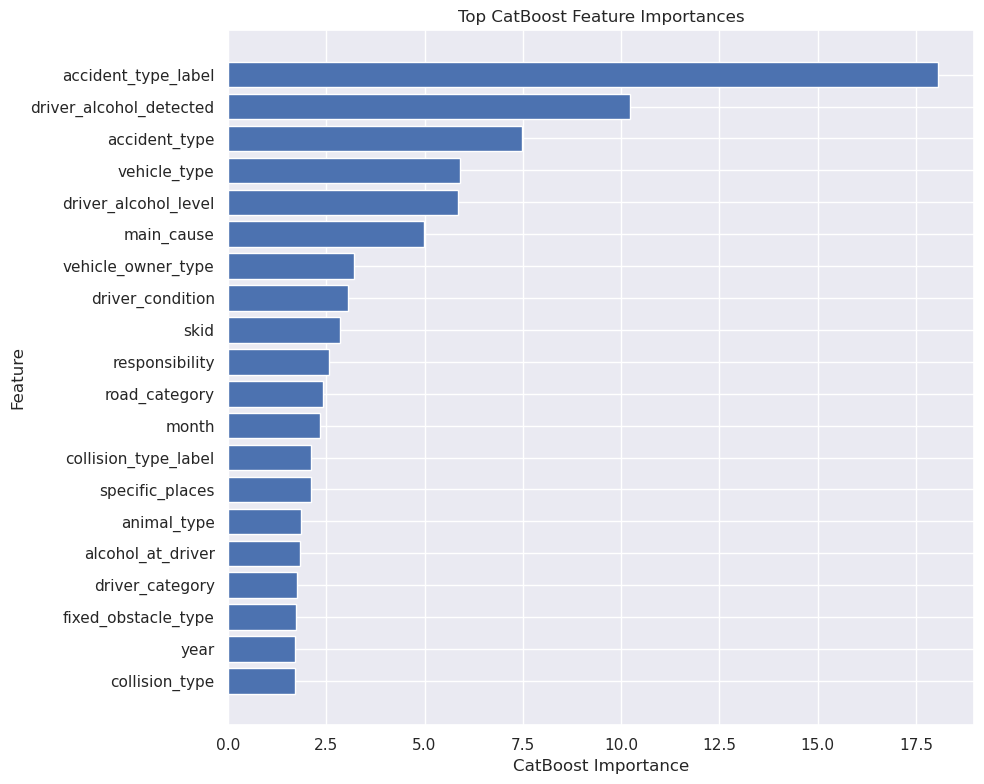

In [25]:
top_cb = cb_fi_df.head(20).sort_values("importance")

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 8))
plt.barh(top_cb["feature"], top_cb["importance"])
plt.xlabel("CatBoost Importance")
plt.ylabel("Feature")
plt.title("Top CatBoost Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(model_cb)
shap_values = explainer.shap_values(X_test_cb)

# for binary classification, shap_values can be list or array depending on version
shap.summary_plot(shap_values, X_test_cb)
import numpy as np
import pandas as pd

shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": X_test_cb.columns,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

print(shap_df.head(20))

CatBoostError: Invalid type for cat_feature[non-default value idx=0,feature_idx=0]=6.0 : cat_features must be integer or string, real number values and NaN values should be converted to string.

The SHAP analysis indicates that accident type is the most influential predictor in the model. The variable accident_type_label has the highest mean absolute SHAP value, suggesting that the nature of the accident itself strongly influences the predicted accident severity. This result is intuitive, as certain accident types are inherently associated with higher risks of injuries or fatalities.

The presence of alcohol-related variables among the most important predictors is also notable. Both driver_alcohol_detected and alcohol_at_driver appear among the top features, indicating that alcohol involvement significantly contributes to the model's prediction of accident severity. This finding aligns with existing research that identifies alcohol impairment as a major factor in severe traffic accidents.

The variable main_cause is also highly ranked, suggesting that the underlying cause of the accident (such as driver inattention, speeding, or failure to yield) plays a substantial role in determining accident outcomes.

Several vehicle-related variables appear in the top features, including vehicle_type, vehicle_owner_type, vehicle_year, and vehicle_make. These variables may capture differences in vehicle characteristics, safety features, or usage patterns that influence accident severity.